In [17]:
!pip install google-cloud-bigquery google-cloud-storage schedule pandas matplotlib seaborn --quiet

In [32]:
from google.colab import auth
auth.authenticate_user()
print("Autenticado", flush=True)

Autenticado


Iniciando ejecución del pipeline completo...

Ejecutando pipeline: 2026-04-22
✓ Conexión a BigQuery establecida

--- PASO 0: Cargando archivos de raw/ a BigQuery ---
✓ yellow_trips_oct cargada desde raw/
✓ yellow_trips_nov cargada desde raw/
✓ yellow_trips_dic cargada desde raw/

--- PASO 1: Limpieza y Transformación ---
✓ Tabla yellow_trips_clean creada
✓ Total registros limpios: 11,599,258

--- PASO 2: Agregación ---
✓ Tabla trips_by_hour generada
✓ Tabla trips_by_zone generada
✓ Tabla tip_by_distance generada

--- PASO 3: Exportando datos limpios a processed/ ---
✓ Datos limpios exportados a processed/
✓ trips_by_hour exportada a results/
✓ trips_by_zone exportada a results/
✓ tip_by_distance exportada a results/

--- PASO 4: Generando gráficas ---


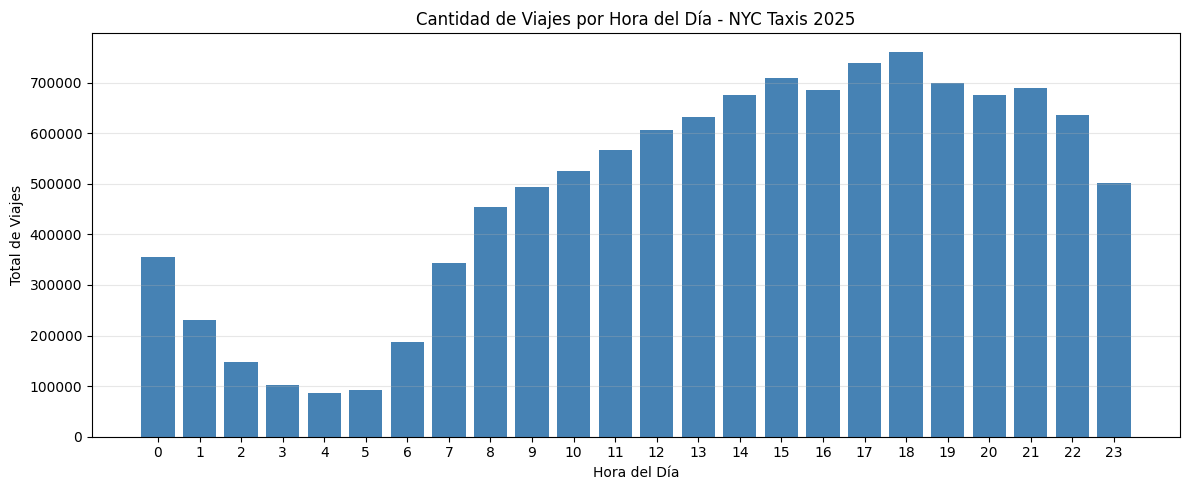

✓ Gráfica 1 generada


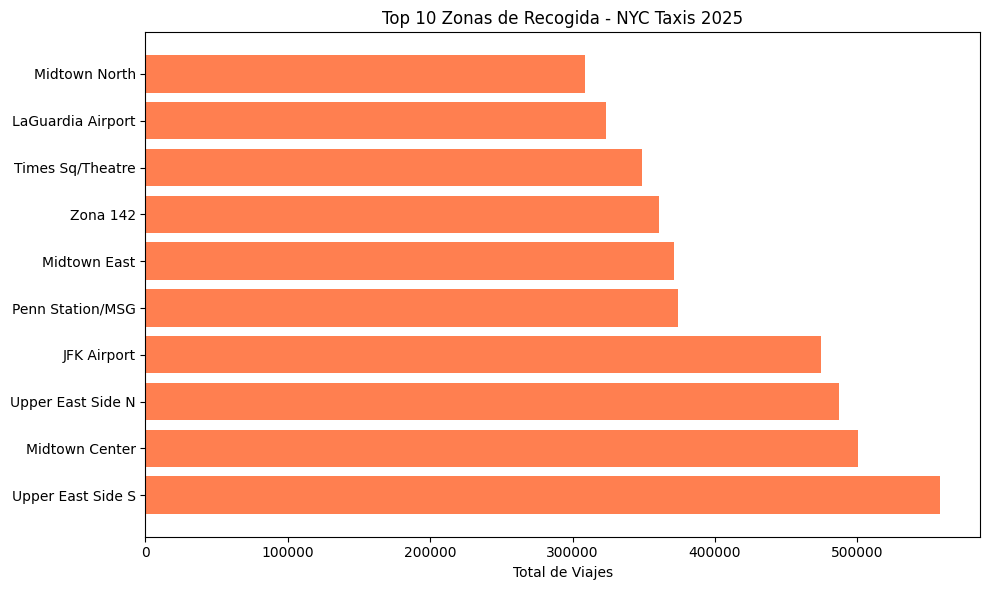

✓ Gráfica 2 generada


/tmp/ipykernel_1913/3590147014.py:197: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_propina, x='distance_range', y='propina_promedio', palette='viridis')


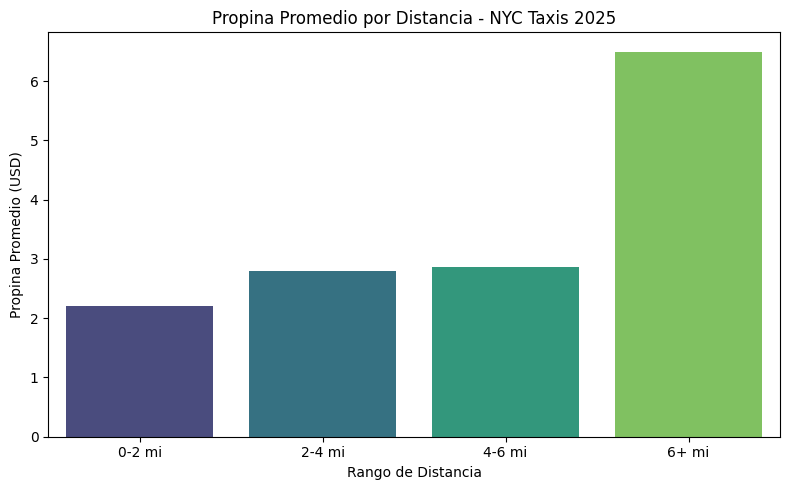

✓ Gráfica 3 generada

--- PASO 5: Subiendo resultados a Cloud Storage ---
✓ grafica_demanda_hora.png subido a results/
✓ grafica_top_zonas.png subido a results/
✓ grafica_propina_dist.png subido a results/

✅ Pipeline completado exitosamente
Fecha y hora: 2026-04-22 23:23:47
Total registros procesados: 11,599,258



In [33]:
import schedule
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import sys

def pipeline_completo():
    print(f"\n{'='*50}", flush=True)
    print(f"Ejecutando pipeline: {datetime.now().strftime('%Y-%m-%d')}", flush=True)
    print(f"{'='*50}", flush=True)

    from google.cloud import bigquery, storage
    client = bigquery.Client(project="nyctaxi-project-494018")
    print("✓ Conexión a BigQuery establecida", flush=True)

    # PASO 0: CARGAR ARCHIVOS DE raw/ A BIGQUERY
    print("\n--- PASO 0: Cargando archivos de raw/ a BigQuery ---", flush=True)
    archivos_raw = [
        {"uri": "gs://proyecto-taxis-nyc-gamp/raw/yellow_tripdata_2025-Octubre.parquet", "tabla": "yellow_trips_oct"},
        {"uri": "gs://proyecto-taxis-nyc-gamp/raw/yellow_tripdata_2025-Noviembre.parquet", "tabla": "yellow_trips_nov"},
        {"uri": "gs://proyecto-taxis-nyc-gamp/raw/yellow_tripdata_2025-Diciembre.parquet", "tabla": "yellow_trips_dic"},
    ]
    for archivo in archivos_raw:
        job_config = bigquery.LoadJobConfig(
            source_format=bigquery.SourceFormat.PARQUET,
            write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
            autodetect=True
        )
        destino = bigquery.TableReference(
            bigquery.DatasetReference("nyctaxi-project-494018", "taxi_analysis"),
            archivo["tabla"]
        )
        load_job = client.load_table_from_uri(
            archivo["uri"],
            destino,
            job_config=job_config
        )
        load_job.result()
        print(f"✓ {archivo['tabla']} cargada desde raw/", flush=True)

    # PASO 1: LIMPIEZA Y TRANSFORMACION
    print("\n--- PASO 1: Limpieza y Transformación ---", flush=True)
    client.query("""
        CREATE OR REPLACE TABLE taxi_analysis.yellow_trips_clean AS
        SELECT
          VendorID, tpep_pickup_datetime, tpep_dropoff_datetime,
          passenger_count, trip_distance, RatecodeID, store_and_fwd_flag,
          PULocationID, DOLocationID, payment_type, fare_amount, extra,
          mta_tax, tip_amount, tolls_amount, improvement_surcharge,
          total_amount, congestion_surcharge, Airport_fee,

          -- TRANSFORMACION 1: Duracion del viaje en minutos
          TIMESTAMP_DIFF(tpep_dropoff_datetime, tpep_pickup_datetime, MINUTE) AS duracion_minutos,

          -- TRANSFORMACION 2: Hora de recogida (0-23)
          EXTRACT(HOUR FROM tpep_pickup_datetime) AS pickup_hour,

          -- TRANSFORMACION 3: Fecha de recogida
          DATE(tpep_pickup_datetime) AS pickup_date,

          -- TRANSFORMACION 4: Dia de semana (1=Domingo, 7=Sabado)
          EXTRACT(DAYOFWEEK FROM tpep_pickup_datetime) AS dia_semana,

          -- TRANSFORMACION 5: Metodo de pago en texto descriptivo
          CASE
            WHEN payment_type = 1 THEN 'Tarjeta'
            WHEN payment_type = 2 THEN 'Efectivo'
            WHEN payment_type = 3 THEN 'Sin cargo'
            ELSE 'Disputa'
          END AS payment_name,
          -- TRANSFORMACION 6: Clasificacion por rango de distancia
          CASE
            WHEN trip_distance < 2 THEN '0-2 mi'
            WHEN trip_distance < 4 THEN '2-4 mi'
            WHEN trip_distance < 6 THEN '4-6 mi'
            ELSE '6+ mi'
          END AS distance_range
          -- UNION de los 3 meses en una sola tabla
        FROM (
          SELECT * FROM taxi_analysis.yellow_trips_oct UNION ALL
          SELECT * FROM taxi_analysis.yellow_trips_nov UNION ALL
          SELECT * FROM taxi_analysis.yellow_trips_dic
        )
        -- LIMPIEZA: eliminar registros invalidos o fuera de rango
        WHERE trip_distance > 0 AND fare_amount > 0 AND total_amount > 0
          AND tpep_pickup_datetime IS NOT NULL
          AND tpep_dropoff_datetime IS NOT NULL
          AND TIMESTAMP_DIFF(tpep_dropoff_datetime, tpep_pickup_datetime, MINUTE) BETWEEN 1 AND 1440
    """).result()
    print("✓ Tabla yellow_trips_clean creada", flush=True)

    # Total de registros
    total = client.query("""
        SELECT COUNT(*) as total
        FROM `nyctaxi-project-494018.taxi_analysis.yellow_trips_clean`
    """).to_dataframe()['total'][0]
    print(f"✓ Total registros limpios: {total:,}", flush=True)

    # PASO 2: AGREGACION
    print("\n--- PASO 2: Agregación ---", flush=True)
    client.query("""
        CREATE OR REPLACE TABLE taxi_analysis.trips_by_hour AS
        SELECT pickup_hour, COUNT(*) AS total_viajes
        FROM taxi_analysis.yellow_trips_clean
        GROUP BY pickup_hour ORDER BY pickup_hour
    """).result()
    print("✓ Tabla trips_by_hour generada", flush=True)

    client.query("""
        CREATE OR REPLACE TABLE taxi_analysis.trips_by_zone AS
        SELECT PULocationID, COUNT(*) AS total_viajes
        FROM taxi_analysis.yellow_trips_clean
        GROUP BY PULocationID ORDER BY total_viajes DESC LIMIT 10
    """).result()
    print("✓ Tabla trips_by_zone generada", flush=True)

    client.query("""
        CREATE OR REPLACE TABLE taxi_analysis.tip_by_distance AS
        SELECT distance_range,
            ROUND(AVG(tip_amount), 2) AS propina_promedio,
            COUNT(*) AS total_viajes
        FROM taxi_analysis.yellow_trips_clean
        GROUP BY distance_range ORDER BY distance_range
    """).result()
    print("✓ Tabla tip_by_distance generada", flush=True)

# PASO 3: EXPORTAR A processed/
    print("\n--- PASO 3: Exportando datos limpios a processed/ ---", flush=True)
    extract_job = client.extract_table(
        "nyctaxi-project-494018.taxi_analysis.yellow_trips_clean",
        "gs://proyecto-taxis-nyc-gamp/processed/yellow_trips_clean_*.parquet",
        job_config=bigquery.ExtractJobConfig(
            destination_format=bigquery.DestinationFormat.PARQUET
        )
    )
    extract_job.result()
    print("✓ Datos limpios exportados a processed/", flush=True)

    # Exportar tablas de agregación a results/
    tablas_agregacion = [
        ("nyctaxi-project-494018.taxi_analysis.trips_by_hour",
         "gs://proyecto-taxis-nyc-gamp/results/trips_by_hour.parquet"),
        ("nyctaxi-project-494018.taxi_analysis.trips_by_zone",
         "gs://proyecto-taxis-nyc-gamp/results/trips_by_zone.parquet"),
        ("nyctaxi-project-494018.taxi_analysis.tip_by_distance",
         "gs://proyecto-taxis-nyc-gamp/results/tip_by_distance.parquet"),
    ]
    for tabla, destino_gcs in tablas_agregacion:
        export_job = client.extract_table(
            tabla,
            destino_gcs,
            job_config=bigquery.ExtractJobConfig(
                destination_format=bigquery.DestinationFormat.PARQUET
            )
        )
        export_job.result()
        nombre = tabla.split(".")[-1]
        print(f"✓ {nombre} exportada a results/", flush=True)

    # PASO 4: GENERAR GRAFICAS
    print("\n--- PASO 4: Generando gráficas ---", flush=True)
    df_hora = client.query("SELECT * FROM taxi_analysis.trips_by_hour ORDER BY pickup_hour").to_dataframe()
    df_zona = client.query("SELECT * FROM taxi_analysis.trips_by_zone ORDER BY total_viajes DESC").to_dataframe()
    df_propina = client.query("SELECT * FROM taxi_analysis.tip_by_distance ORDER BY distance_range").to_dataframe()

    plt.figure(figsize=(12, 5))
    plt.bar(df_hora['pickup_hour'], df_hora['total_viajes'], color='steelblue')
    plt.title('Cantidad de Viajes por Hora del Día - NYC Taxis 2025')
    plt.xlabel('Hora del Día')
    plt.ylabel('Total de Viajes')
    plt.xticks(range(0, 24))
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('grafica_demanda_hora.png', dpi=150)
    plt.show()
    plt.close()
    print("✓ Gráfica 1 generada", flush=True)

    zone_names = {
        132: 'JFK Airport', 138: 'LaGuardia Airport', 161: 'Midtown Center',
        162: 'Midtown East', 163: 'Midtown North', 230: 'Times Sq/Theatre',
        236: 'Upper East Side N', 237: 'Upper East Side S',
        186: 'Penn Station/MSG', 164: 'Midtown South'
    }
    df_zona['zona_nombre'] = df_zona['PULocationID'].map(zone_names).fillna('Zona ' + df_zona['PULocationID'].astype(str))
    plt.figure(figsize=(10, 6))
    plt.barh(df_zona['zona_nombre'], df_zona['total_viajes'], color='coral')
    plt.title('Top 10 Zonas de Recogida - NYC Taxis 2025')
    plt.xlabel('Total de Viajes')
    plt.tight_layout()
    plt.savefig('grafica_top_zonas.png', dpi=150)
    plt.show()
    plt.close()
    print("✓ Gráfica 2 generada", flush=True)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_propina, x='distance_range', y='propina_promedio', palette='viridis')
    plt.title('Propina Promedio por Distancia - NYC Taxis 2025')
    plt.xlabel('Rango de Distancia')
    plt.ylabel('Propina Promedio (USD)')
    plt.tight_layout()
    plt.savefig('grafica_propina_dist.png', dpi=150)
    plt.show()
    plt.close()
    print("✓ Gráfica 3 generada", flush=True)

    # PASO 5: SUBIR A results/
    print("\n--- PASO 5: Subiendo resultados a Cloud Storage ---", flush=True)
    storage_client = storage.Client(project="nyctaxi-project-494018")
    bucket = storage_client.bucket("proyecto-taxis-nyc-gamp")
    for archivo in ['grafica_demanda_hora.png', 'grafica_top_zonas.png', 'grafica_propina_dist.png']:
        bucket.blob(f"results/{archivo}").upload_from_filename(archivo)
        print(f"✓ {archivo} subido a results/", flush=True)

    print(f"\n✅ Pipeline completado exitosamente", flush=True)
    print(f"Fecha: {datetime.now().strftime('%Y-%m-%d')}", flush=True)
    print(f"Total registros procesados: {total:,}", flush=True)
    print(f"{'='*50}\n", flush=True)

# Ejecutar inmediatamente
print("Iniciando ejecución del pipeline completo...", flush=True)
pipeline_completo()